In [1]:
import os
import random
import pandas as pd
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
from matplotlib import pyplot as plt
from pathlib import Path
from os.path import join
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split

os.environ["KERAS_BACKEND"] = "torch"
#os.environ["KERAS_BACKEND"] = "jax" # you can also use tensorflow or torch

import keras_core as keras
import keras_cv
import keras
from keras import ops
import tensorflow as tf

from glob import glob
from tqdm.notebook import tqdm
import joblib

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import torch.optim as optim
from torch import nn
import warnings
warnings.filterwarnings("ignore")

Using PyTorch backend.


In [2]:
# 1) Inspect your current working directory

print("CWD is:", Path.cwd())   # see where your notebook is running

# 2) Define BASE_DIR as the project root (one level up from src/)
BASE_DIR = Path.cwd()

# 3) Point at your data folder

data_dir = "data/planttraits2024"
base = BASE_DIR / data_dir
# 4) Build all of your file-paths off DATA_DIR
sub = base / 'sample_submission.csv'
trgts = base / 'target_name_meta.tsv'
train_path = base / 'train.csv'
test_path = base / 'test.csv'
train_image_path = base / 'train_images'
test_image_path = base / 'test_images'

print(train_path, test_path, train_image_path, test_image_path)

SEED = 42
IMAGE_SIZE = [512, 512]
BATCH_SIZE = 24
EPOCHS = 8
TARGET_COLS  =['X4_mean', 'X11_mean', 'X18_mean', 'X26_mean', 'X50_mean', 'X3112_mean']

CWD is: C:\Users\Tony PC\PycharmProjects\tiff_project
C:\Users\Tony PC\PycharmProjects\tiff_project\data\planttraits2024\train.csv C:\Users\Tony PC\PycharmProjects\tiff_project\data\planttraits2024\test.csv C:\Users\Tony PC\PycharmProjects\tiff_project\data\planttraits2024\train_images C:\Users\Tony PC\PycharmProjects\tiff_project\data\planttraits2024\test_images


In [3]:
print("TensorFlow:", tf.__version__)
print("Keras:", keras.__version__)
print("KerasCV:", keras_cv.__version__)

TensorFlow: 2.19.0
Keras: 3.9.2
KerasCV: 0.9.0


In [4]:
class CFG:
    verbose = 1  # Verbosity
    seed = 42  # Random seed
    preset = "efficientnetv2_b2_imagenet"  # Name of pretrained classifier
    image_size = [224, 224]  # Input image size
    epochs = 10 # Training epochs
    batch_size = 128  # Batch size
    lr_mode = "step" # LR scheduler mode from one of "cos", "step", "exp"
    drop_remainder = True  # Drop incomplete batches
    num_classes = 6 # Number of classes in the dataset
    num_folds = 2 # Number of folds to split the dataset
    fold = 0 # Which fold to set as validation data
    class_names = ['X4_mean', 'X11_mean', 'X18_mean',
                   'X26_mean', 'X50_mean', 'X3112_mean',]
    aux_class_names = list(map(lambda x: x.replace("mean","sd"), class_names))
    num_classes = len(class_names)
    aux_num_classes = len(aux_class_names)

In [5]:
keras.utils.set_random_seed(CFG.seed)

In [6]:
# Train + Valid
import zipfile
import io

zip_path = "data/planttraits2024.zip"
extract_to = "data/planttraits2024"
with zipfile.ZipFile(zip_path, "r") as zip_ref:
     zip_ref.extractall(extract_to)

In [7]:
# 1) Loadtrain and test data
df = pd.read_csv(train_path)
df['image_path'] = f'{train_image_path}/'+df['id'].astype(str)+'.jpeg'
df.loc[:, CFG.aux_class_names] = df.loc[:, CFG.aux_class_names].fillna(-1)
display(df.head(2))


test_df = pd.read_csv(test_path)
test_df['image_path'] = f'{train_image_path}/'+test_df['id'].astype(str)+'.jpeg'
FEATURE_COLS = test_df.columns[1:-1].tolist()
display(test_df.head(2))


,id,WORLDCLIM_BIO1_annual_mean_temperature,WORLDCLIM_BIO12_annual_precipitation,WORLDCLIM_BIO13.BIO14_delta_precipitation_of_wettest_and_dryest_month,WORLDCLIM_BIO15_precipitation_seasonality,WORLDCLIM_BIO4_temperature_seasonality,WORLDCLIM_BIO7_temperature_annual_range,SOIL_bdod_0.5cm_mean_0.01_deg,SOIL_bdod_100.200cm_mean_0.01_deg,SOIL_bdod_15.30cm_mean_0.01_deg,...,X26_mean,X50_mean,X3112_mean,X4_sd,X11_sd,X18_sd,X26_sd,X50_sd,X3112_sd,image_path
0,192027691,12.235703,374.466675,62.524445,72.256844,773.592041,33.277779,125,149,136,...,1.243779,1.849375,50.216034,0.008921,1.601473,0.025441,0.153608,0.279610,15.045054,C:\Users\Tony PC\PycharmProjects\tiff_project\...
1,195542235,17.270555,90.239998,10.351111,38.220940,859.193298,40.009777,124,144,138,...,0.642940,1.353468,574.098472,0.003102,0.258078,0.000866,0.034630,0.010165,11.004477,C:\Users\Tony PC\PycharmProjects\tiff_project\...


,id,WORLDCLIM_BIO1_annual_mean_temperature,WORLDCLIM_BIO12_annual_precipitation,WORLDCLIM_BIO13.BIO14_delta_precipitation_of_wettest_and_dryest_month,WORLDCLIM_BIO15_precipitation_seasonality,WORLDCLIM_BIO4_temperature_seasonality,WORLDCLIM_BIO7_temperature_annual_range,SOIL_bdod_0.5cm_mean_0.01_deg,SOIL_bdod_100.200cm_mean_0.01_deg,SOIL_bdod_15.30cm_mean_0.01_deg,...,VOD_X_1997_2018_multiyear_mean_m04,VOD_X_1997_2018_multiyear_mean_m05,VOD_X_1997_2018_multiyear_mean_m06,VOD_X_1997_2018_multiyear_mean_m07,VOD_X_1997_2018_multiyear_mean_m08,VOD_X_1997_2018_multiyear_mean_m09,VOD_X_1997_2018_multiyear_mean_m10,VOD_X_1997_2018_multiyear_mean_m11,VOD_X_1997_2018_multiyear_mean_m12,image_path
0,201238668,8.086756,2246.500000,127.321426,20.423418,353.381042,17.535713,80,109,90,...,0.389460,0.387536,0.374910,0.363712,0.364623,0.379435,0.388294,0.398887,0.397853,C:\Users\Tony PC\PycharmProjects\tiff_project\...
1,202310319,10.844286,495.871429,28.023809,18.738306,786.554382,29.292856,130,155,142,...,0.300813,0.332776,0.314386,0.291168,0.280947,0.277623,0.276503,0.271212,0.272672,C:\Users\Tony PC\PycharmProjects\tiff_project\...


In [ ]:
# 2) Binning & stratified split
df["final_bin"] = pd.qcut(df[CFG.class_names[0]], q=CFG.num_folds, labels=False)

# ── 2b) Label-Outlier Removal (apply **only** to train_df) ────────────────
print(f"▶️  Train before label cleanup: {df.shape}")
pct = 99
thresholds = {col: np.percentile(df[col], pct) for col in CFG.class_names}
for col, t in thresholds.items():
    df = df[df[col] < t]
print(f"▶️  Train after  {pct}th-pctile filter: {df.shape}")

# Randomly use 20% of training data and split them into train & val sets
part_df = df.sample(frac=0.2, random_state=42)

train_df, valid_df = train_test_split(
    part_df, test_size=0.2, stratify=part_df["final_bin"], random_state=42
)

# (drop the helper column if you want)
train_df = train_df.drop(columns="final_bin")
valid_df = valid_df.drop(columns="final_bin")
print(f"Train size: {len(train_df)}")
print(f"Validation size: {len(valid_df)}")
print(f"Test size: {len(test_df)}")


▶️  Train before label cleanup: (55489, 178)
▶️  Train after  99th-pctile filter: (52622, 178)
Train size: 8419
Validation size: 2105
Test size: 6545


              count         mean          std       min         25%  \
X4_mean     52622.0     0.518088     0.144270 -0.981767    0.409921   
X11_mean    52622.0    15.862905     7.519303  1.186970   10.853504   
X18_mean    52622.0     2.985530     4.955304  0.002156    0.303461   
X26_mean    52622.0    33.862752   121.079299  0.000179    0.531707   
X50_mean    52622.0     1.605841     0.640075  0.076517    1.175901   
X3112_mean  52622.0  1769.089164  2873.445301  0.022352  257.219740   

                   50%          75%           max  
X4_mean       0.505172     0.618853      0.920310  
X11_mean     15.229621    19.624518     50.800531  
X18_mean      0.686737     3.142266     28.491554  
X26_mean      2.340310    13.206144   1395.838685  
X50_mean      1.472342     1.902524      4.451823  
X3112_mean  702.251700  2040.142221  24518.421496  


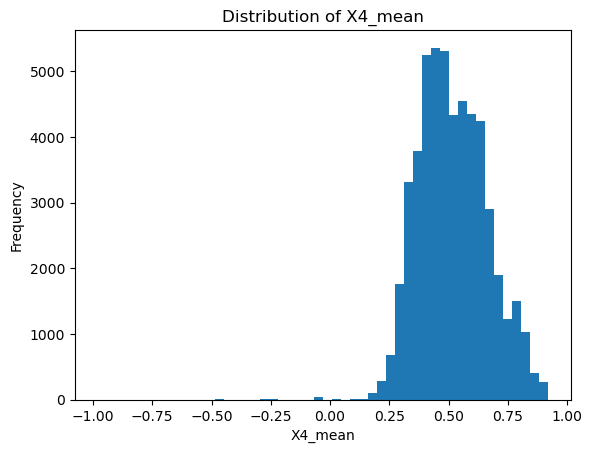

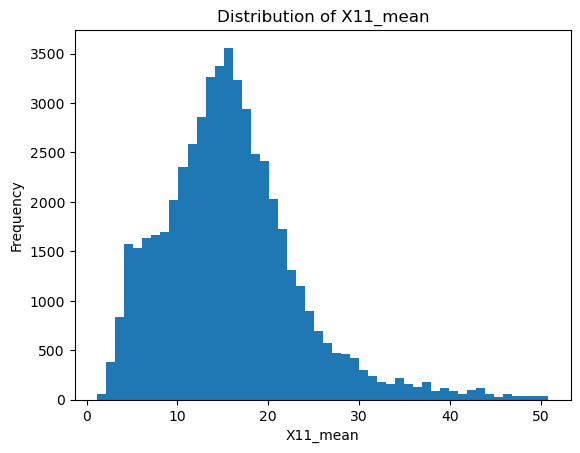

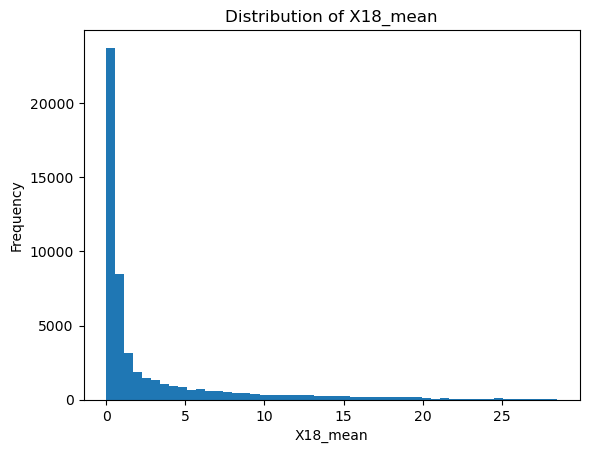

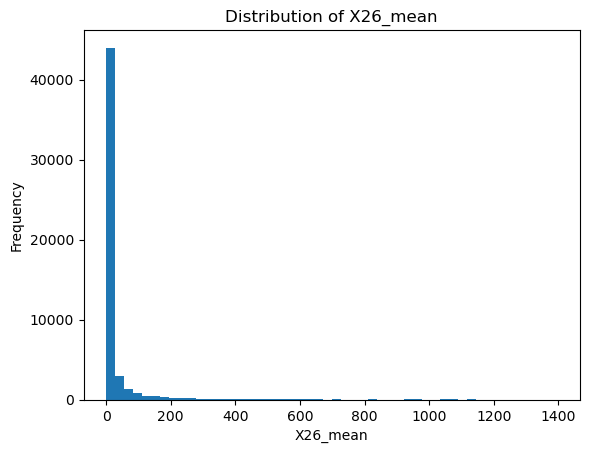

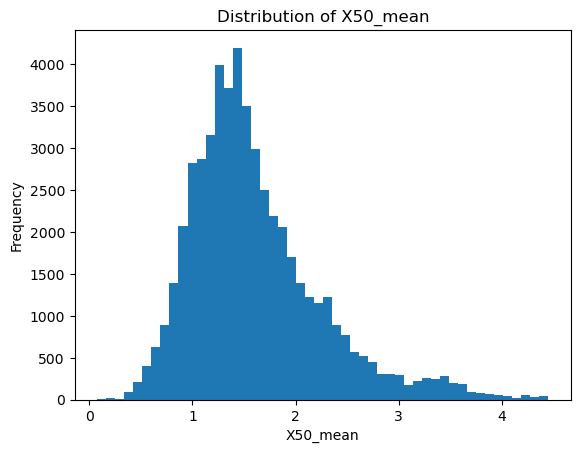

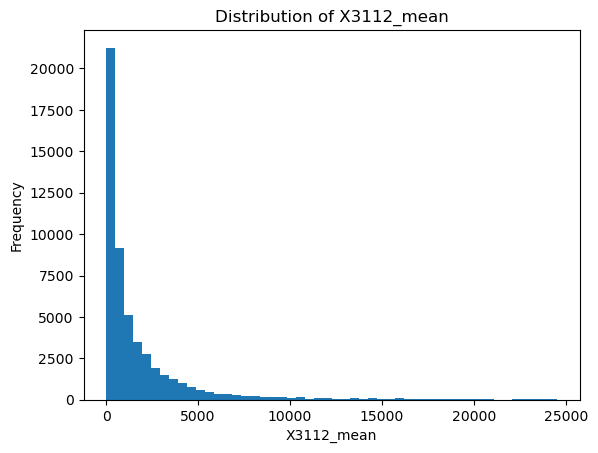

In [35]:
# 8) # Summary stats for all target features

print(df[CFG.class_names].describe().T)

# Histograms for each trait
for trait in CFG.class_names:
    plt.figure()
    plt.hist(df[trait].dropna(), bins=50)
    plt.title(f"Distribution of {trait}")
    plt.xlabel(trait)
    plt.ylabel("Frequency")
    plt.show()
    

In [14]:
def build_augmenter():
    # Define augmentations
    aug_layers = [
        keras_cv.layers.RandomBrightness(factor=0.1, value_range=(0, 1)),
        keras_cv.layers.RandomContrast(factor=0.1, value_range=(0, 1)),
        keras_cv.layers.RandomSaturation(factor=(0.45, 0.55)),
        keras_cv.layers.RandomHue(factor=0.1, value_range=(0, 1)),
        keras_cv.layers.RandomCutout(height_factor=(0.06, 0.15), width_factor=(0.06, 0.15)),
        keras_cv.layers.RandomFlip(mode="horizontal_and_vertical"),
        keras_cv.layers.RandomZoom(height_factor=(0.05, 0.15)),
        keras_cv.layers.RandomRotation(factor=(0.01, 0.05)),
    ]

    # Apply augmentations to random samples
    aug_layers = [keras_cv.layers.RandomApply(x, rate=0.5) for x in aug_layers]

    # Build augmentation layer
    augmenter = keras_cv.layers.Augmenter(aug_layers)

    # Apply augmentations
    def augment(inp, label):
        images = inp["images"]
        aug_data = {"images": images}
        aug_data = augmenter(aug_data)
        inp["images"] = aug_data["images"]
        return inp, label
    return augment


def build_decoder(with_labels=True, target_size=CFG.image_size):
    def decode_image(inp):
        path = inp["images"]

        # Read jpeg image
        file_bytes = tf.io.read_file(path)
        image = tf.io.decode_jpeg(file_bytes)

        # Resize
        image = tf.image.resize(image, size=target_size, method="area")

        # Rescale image
        image = tf.cast(image, tf.float32)
        image /= 255.0

        # Reshape
        image = tf.reshape(image, [*target_size, 3])

        inp["images"] = image
        return inp

    def decode_label(label, num_classes):
        label = tf.cast(label, tf.float32)
        label = tf.reshape(label, [num_classes])
        return label

    def decode_with_labels(inp, labels=None):
        inp = decode_image(inp)
        label = decode_label(labels[0], CFG.num_classes)
        aux_label = decode_label(labels[1], CFG.aux_num_classes)
        return (inp, (label, aux_label))

    return decode_with_labels if with_labels else decode_image


def build_dataset(
    paths,
    features,
    labels=None,
    aux_labels=None,
    batch_size=32,
    cache=True,
    decode_fn=None,
    augment_fn=None,
    augment=False,
    repeat=True,
    shuffle=1024,
    cache_dir="",
    drop_remainder=False,
):
    if cache_dir != "" and cache is True:
        os.makedirs(cache_dir, exist_ok=True)

    if decode_fn is None:
        decode_fn = build_decoder(labels is not None or aux_labels is not None)

    if augment_fn is None:
        augment_fn = build_augmenter()

    AUTO = tf.data.experimental.AUTOTUNE

    inp = {"images": paths, "features": features}
    slices = (inp, (labels, aux_labels)) if labels is not None else inp

    ds = tf.data.Dataset.from_tensor_slices(slices)
    ds = ds.map(decode_fn, num_parallel_calls=AUTO)
    ds = ds.cache(cache_dir) if cache else ds
    ds = ds.repeat() if repeat else ds
    if shuffle:
        ds = ds.shuffle(shuffle, seed=CFG.seed)
        opt = tf.data.Options()
        opt.experimental_deterministic = False
        ds = ds.with_options(opt)
    ds = ds.batch(batch_size, drop_remainder=drop_remainder)
    ds = ds.map(augment_fn, num_parallel_calls=AUTO) if augment else ds
    ds = ds.prefetch(AUTO)
    return ds

In [15]:
print("GPUs available:", tf.config.list_physical_devices('GPU'))

GPUs available: []


In [ ]:
from sklearn.preprocessing import StandardScaler

# Normalize features
scaler = StandardScaler()
train_features = scaler.fit_transform(train_df[FEATURE_COLS].astype(np.float32).values)
valid_features = scaler.transform(valid_df[FEATURE_COLS].astype(np.float32).values)

# Train
train_paths = train_df.image_path.values
train_labels = train_df[CFG.class_names].astype(np.float32).values
train_aux_labels = train_df[CFG.aux_class_names].astype(np.float32).values
train_ds = build_dataset(train_paths, train_features, train_labels, train_aux_labels,
                         batch_size=CFG.batch_size,
                         repeat=True, shuffle=True, augment=True, cache=False)

# Valid
valid_paths = valid_df.image_path.values
valid_labels = valid_df[CFG.class_names].astype(np.float32).values
valid_aux_labels = valid_df[CFG.aux_class_names].astype(np.float32).values
valid_ds = build_dataset(valid_paths, valid_features, valid_labels, valid_aux_labels,
                         batch_size=CFG.batch_size,
                         repeat=False, shuffle=False, augment=False, cache=False)

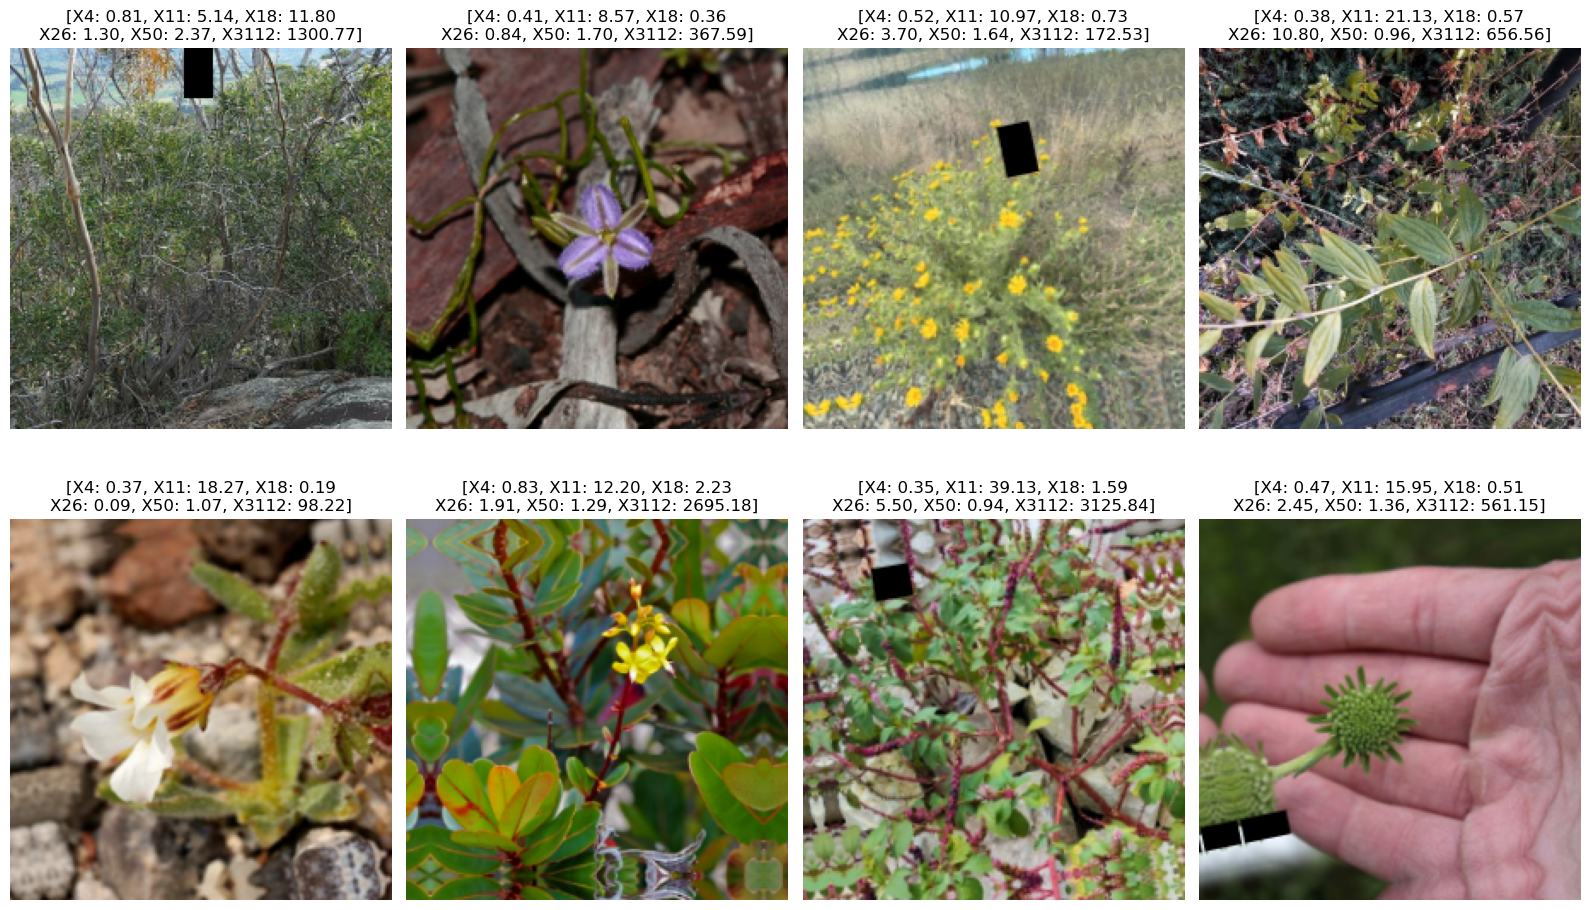

In [ ]:
# Print the image

inps, tars = next(iter(train_ds))
imgs = inps["images"]
num_imgs, num_cols = 8, 4

plt.figure(figsize=(4 * num_cols, num_imgs // num_cols * 5))
for i, (img, tar) in enumerate(zip(imgs[:num_imgs], tars[0][:num_imgs])):
    plt.subplot(num_imgs // num_cols, num_cols, i + 1)
    img = img. numpy()
    tar = tar.numpy()

    img = (img - img.min()) / (img.max() + 1e-4)

    formatted_tar = "\n".join(
        [
            ", ".join(
                f"{name.replace('_mean','')}: {val:.2f}"
                for name, val in zip(CFG.class_names[j : j + 3], tar[j : j + 3])
            )
            for j in range(0, len(CFG.class_names), 3)
        ]
    )

    plt.imshow(img)
    plt.title(f"[{formatted_tar}]")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
from keras import ops

class R2Loss(keras.losses.Loss):
    def __init__(self, use_mask=False, name="r2_loss"):
        super().__init__(name=name)
        self.use_mask = use_mask

    def call(self, y_true, y_pred):
        if self.use_mask:
            mask = (y_true != -1)
            y_true = ops.where(mask, y_true, 0.0)
            y_pred = ops.where(mask, y_pred, 0.0)
        SS_res = ops.sum(ops.square(y_true - y_pred), axis=0)  # (B, C) -> (C,)
        SS_tot = ops.sum(ops.square(y_true - ops.mean(y_true, axis=0)), axis=0)  # (B, C) -> (C,)
        r2_loss = SS_res / (SS_tot + 1e-6)  # (C,)
        return ops.mean(r2_loss)  # ()

class R2Metric(keras.metrics.Metric):
    def __init__(self, name="r2", **kwargs):
        super(R2Metric, self).__init__(name=name, **kwargs)
        self.SS_res = self.add_weight(name='SS_res', shape=(6,), initializer='zeros')
        self.SS_tot = self.add_weight(name='SS_tot', shape=(6,) ,initializer='zeros')
        self.num_samples = self.add_weight(name='num_samples', initializer='zeros')

    def update_state(self, y_true, y_pred, sample_weight=None):
        SS_res = ops.sum(ops.square(y_true - y_pred), axis=0)
        SS_tot = ops.sum(ops.square(y_true - ops.mean(y_true, axis=0)), axis=0)
        self.SS_res.assign_add(SS_res)
        self.SS_tot.assign_add(SS_tot)
        self.num_samples.assign_add(ops.cast(ops.shape(y_true)[0], "float32"))

    def result(self):
        r2 = 1 - self.SS_res / (self.SS_tot + 1e-6)
        return ops.mean(r2)

    def reset_states(self):
        self.total_SS_res.assign(0)
        self.total_SS_tot.assign(0)
        self.num_samples.assign(0)

'\nimport tensorflow as tf\nfrom tensorflow import keras\n\nclass RSquared(keras.metrics.Metric):\n    def __init__(self, name="r2", **kwargs):\n        super().__init__(name=name, **kwargs)\n        self.sse = self.add_weight(name="sse", initializer="zeros")\n        self.sst = self.add_weight(name="sst", initializer="zeros")\n\n    def update_state(self, y_true, y_pred, sample_weight=None):\n        y_true = tf.reshape(y_true, [-1])\n        y_pred = tf.reshape(y_pred, [-1])\n        error = y_true - y_pred\n        self.sse.assign_add(tf.reduce_sum(tf.square(error)))\n        mean_true = tf.reduce_mean(y_true)\n        self.sst.assign_add(tf.reduce_sum(tf.square(y_true - mean_true)))\n\n    def result(self):\n        return 1.0 - (self.sse / (self.sst + tf.keras.backend.epsilon()))\n\n    def reset_states(self):\n        self.sse.assign(0.0)\n        self.sst.assign(0.0)\n\nclass CustomMSE(keras.losses.Loss):\n    def __init__(self, name="mse_loss"):\n        super().__init__(name=n

In [21]:
# Define input layers
from tensorflow.keras import metrics, optimizers
from tensorflow.keras.metrics import (MeanAbsoluteError, MeanSquaredError, RootMeanSquaredError, MeanAbsolutePercentageError)

img_input = keras.Input(shape=(*CFG.image_size, 3), name="images")
feat_input = keras.Input(shape=(len(FEATURE_COLS),), name="features")

# Branch for image input
backbone = keras_cv.models.EfficientNetV2Backbone.from_preset(CFG.preset)

# 🔒 Freeze all layers in the image backbone
backbone.trainable = False

x1 = backbone(img_input)
x1 = keras.layers.GlobalAveragePooling2D()(x1)
x1 = keras.layers.Dropout(0.1)(x1)

# Branch for tabular/feature input
x2 = keras.layers.Dense(326, activation="selu")(feat_input)
x2 = keras.layers.Dense(64, activation="selu")(x2)
x2 = keras.layers.Dropout(0.1)(x2)

# Concatenate both branches
concat = keras.layers.Concatenate()([x1, x2])

# Output layer
out1 = keras.layers.Dense(CFG.num_classes, activation=None, name="head")(concat)
out2 = keras.layers.Dense(CFG.aux_num_classes, activation="relu", name="aux_head")(concat)
out = {"head": out1, "aux_head":out2}

# Build model
model = keras.models.Model([img_input, feat_input], out)

# Compile the model
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=3e-4),  # used to be 1e-4
    loss={
        "head": R2Loss(use_mask=False),
        "aux_head": R2Loss(use_mask=True), # use_mask to ignore `NaN` auxiliary labels
    },
    loss_weights={"head": 1.0, "aux_head": 0.3},  # more weight to main task
    metrics= {"head": [
            MeanAbsoluteError(name="mae"),
            MeanSquaredError(name="mse"),
            R2Metric()]})

# Model Summary
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ images (InputLayer) │ (None, 224, 224,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ features            │ (None, 163)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ efficient_net_v2b2… │ (None, 7, 7,      │  8,769,374 │ images[0][0]      │
│ (EfficientNetV2Bac… │ 1408)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 326)       │     53,464 │ features[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1408)      │          0 │ efficient_net_v2… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │     20,928 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 1408)      │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 1472)      │          0 │ dropout[0][0],    │
│ (Concatenate)       │                   │            │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ aux_head (Dense)    │ (None, 6)         │      8,838 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ head (Dense)        │ (None, 6)         │      8,838 │ concatenate[0][0] │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 8,861,442 (33.80 MB)

 Trainable params: 92,068 (359.64 KB)

 Non-trainable params: 8,769,374 (33.45 MB)

In [24]:
ckpt_cb = keras.callbacks.ModelCheckpoint(
    "best_model.keras",
    monitor="val_head_r2",
    save_best_only=True,
    save_weights_only=False,
    mode="max",
    initial_value_threshold=-np.inf,
)

In [25]:
history = model.fit(
    train_ds,
    epochs=20,
    steps_per_epoch=len(train_df)//CFG.batch_size,
    validation_data=valid_ds,
    callbacks=[ckpt_cb],
    verbose=1,
)

Epoch 1/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 40s 551ms/step - aux_head_loss: 2.9687 - head_loss: 1.0915 - head_mae: 35.8464 - head_mse: 84793.4453 - head_r2: -0.0846 - loss: 1.9821 - val_aux_head_loss: 1.5912 - val_head_loss: 0.9984 - val_head_mae: 35.9941 - val_head_mse: 80229.3594 - val_head_r2: 0.0075 - val_loss: 1.4757
Epoch 2/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 34s 529ms/step - aux_head_loss: 1.6253 - head_loss: 1.0148 - head_mae: 36.1749 - head_mse: 87729.8125 - head_r2: -0.0102 - loss: 1.5024 - val_aux_head_loss: 1.3825 - val_head_loss: 0.9866 - val_head_mae: 35.8799 - val_head_mse: 80055.3984 - val_head_r2: 0.0190 - val_loss: 1.4013
Epoch 3/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 32s 498ms/step - aux_head_loss: 1.4118 - head_loss: 1.0037 - head_mae: 36.3457 - head_mse: 85438.2969 - head_r2: -0.0010 - loss: 1.4272 - val_aux_head_loss: 1.2509 - val_head_loss: 0.9799 - val_head_mae: 35.7557 - val_head_mse: 79886.6641 - val_head_r2: 0.0251 - val_loss: 1.3551
Epoch 4/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 38s 591m

In [26]:
model.save(base / "planttraits_model.keras")
print("✔️ Model saved to base/planttraits_model.keras")

✔️ Model saved to base/planttraits_model.keras


In [27]:
print(history.history.keys())

dict_keys(['aux_head_loss', 'head_loss', 'head_mae', 'head_mse', 'head_r2', 'loss', 'val_aux_head_loss', 'val_head_loss', 'val_head_mae', 'val_head_mse', 'val_head_r2', 'val_loss'])


In [28]:
test_df = pd.read_csv(test_path)
test_df['image_path'] = f'{test_image_path}/'+test_df['id'].astype(str)+'.jpeg'
FEATURE_COLS = test_df.columns[1:-1].tolist()
display(test_df.head(2))

test_paths = test_df.image_path.values
test_features = scaler.transform(test_df[FEATURE_COLS].values)
test_ds = build_dataset(test_paths, test_features, batch_size=CFG.batch_size,
                         repeat=False, shuffle=False, augment=False, cache=False)

preds = model.predict(test_ds)["head"]

pred_df = test_df[["id"]].copy()
target_cols = [x.replace("_mean","") for x in CFG.class_names]
pred_df[target_cols] = preds.tolist()

#sub_df = pd.read_csv(sub)
#sub_df = sub_df[["id"]].copy()
#sub_df = sub_df.merge(pred_df, on="id", how="left")
#sub_df.to_csv("submission.csv", index=False)
#sub_df.head()
pred_df.to_csv("submission2.csv", index=False)
pred_df.head()

,id,WORLDCLIM_BIO1_annual_mean_temperature,WORLDCLIM_BIO12_annual_precipitation,WORLDCLIM_BIO13.BIO14_delta_precipitation_of_wettest_and_dryest_month,WORLDCLIM_BIO15_precipitation_seasonality,WORLDCLIM_BIO4_temperature_seasonality,WORLDCLIM_BIO7_temperature_annual_range,SOIL_bdod_0.5cm_mean_0.01_deg,SOIL_bdod_100.200cm_mean_0.01_deg,SOIL_bdod_15.30cm_mean_0.01_deg,...,VOD_X_1997_2018_multiyear_mean_m04,VOD_X_1997_2018_multiyear_mean_m05,VOD_X_1997_2018_multiyear_mean_m06,VOD_X_1997_2018_multiyear_mean_m07,VOD_X_1997_2018_multiyear_mean_m08,VOD_X_1997_2018_multiyear_mean_m09,VOD_X_1997_2018_multiyear_mean_m10,VOD_X_1997_2018_multiyear_mean_m11,VOD_X_1997_2018_multiyear_mean_m12,image_path
0,201238668,8.086756,2246.500000,127.321426,20.423418,353.381042,17.535713,80,109,90,...,0.389460,0.387536,0.374910,0.363712,0.364623,0.379435,0.388294,0.398887,0.397853,C:\Users\Tony PC\PycharmProjects\tiff_project\...
1,202310319,10.844286,495.871429,28.023809,18.738306,786.554382,29.292856,130,155,142,...,0.300813,0.332776,0.314386,0.291168,0.280947,0.277623,0.276503,0.271212,0.272672,C:\Users\Tony PC\PycharmProjects\tiff_project\...


52/52 ━━━━━━━━━━━━━━━━━━━━ 12s 228ms/step


,id,X4,X11,X18,X26,X50,X3112
0,201238668,-0.255423,0.914132,0.273944,0.697242,-0.154777,42.141327
1,202310319,-0.264835,0.586890,-0.165133,0.381244,-0.224021,44.040298
2,202604412,-0.463158,-0.213148,-0.238073,0.192293,-0.397572,39.283875
3,201353439,-0.045009,1.514062,0.195886,0.766805,0.038570,46.141556
4,195351745,-0.217402,0.379856,-0.082162,0.118913,-0.121583,37.745632


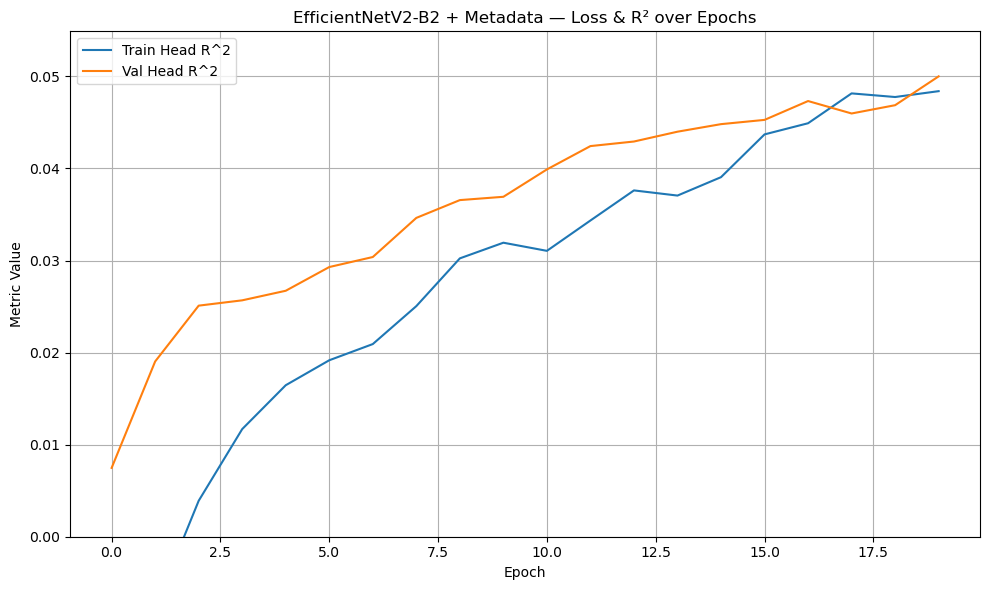

In [29]:
plt.figure(figsize=(10, 6))

plt.plot(history.history["head_r2"], label="Train Head R^2")
plt.plot(history.history["val_head_r2"], label="Val Head R^2")

plt.title(f"EfficientNetV2-B2 + Metadata — Loss & R² over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Metric Value")
plt.ylim(bottom=0)
plt.legend(loc="best")
plt.grid(True)
plt.tight_layout()
plt.show()

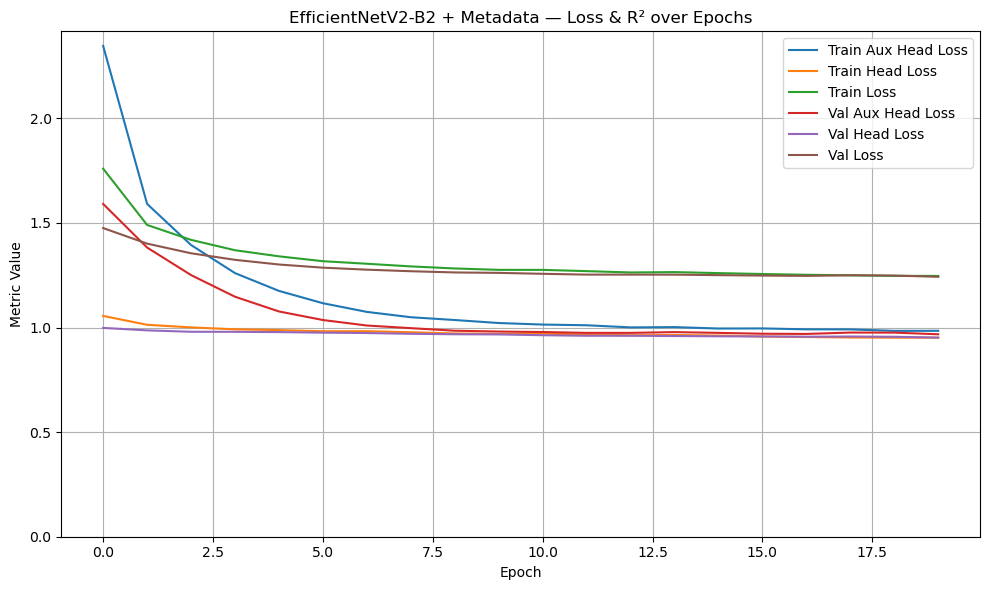

In [30]:
plt.figure(figsize=(10, 6))

plt.plot(history.history["aux_head_loss"], label="Train Aux Head Loss")
plt.plot(history.history["head_loss"], label="Train Head Loss")
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_aux_head_loss"], label="Val Aux Head Loss")
plt.plot(history.history["val_head_loss"], label="Val Head Loss")
plt.plot(history.history["val_loss"], label="Val Loss")

plt.title(f"EfficientNetV2-B2 + Metadata — Loss & R² over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Metric Value")
plt.ylim(bottom=0)
plt.legend(loc="best")
plt.grid(True)
plt.tight_layout()
plt.show()

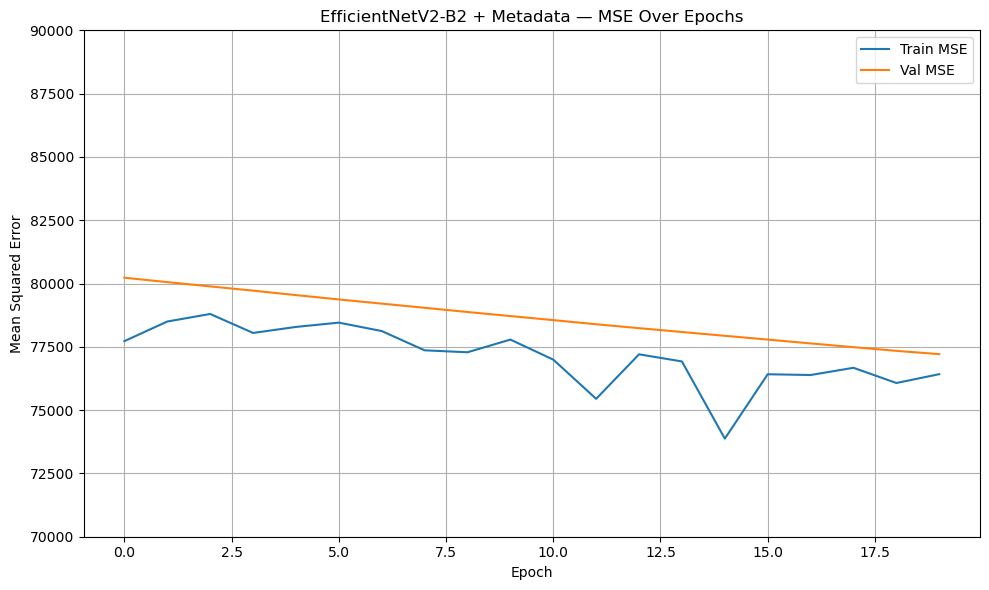

In [34]:
plt.figure(figsize=(10, 6))

plt.plot(history.history["head_mse"], label="Train MSE")
plt.plot(history.history["val_head_mse"], label="Val MSE")

plt.title("EfficientNetV2-B2 + Metadata — MSE Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error")
plt.ylim(bottom=0)
plt.legend(loc="best")
plt.ylim(70000, 90000)
plt.grid(True)
plt.tight_layout()
plt.show()

In [31]:
# Best Result
best_R2 = max(history.history['val_head_r2'])
best_Epoch = np.argmax(history.history['val_head_r2']) + 1
print("#" * 10 + " Result " + "#" * 10)
print(f"Best R2: {best_R2:.5f}")
print(f"Best Epoch: {best_Epoch}")
print("#" * 28)

########## Result ##########
Best R2: 0.05001
Best Epoch: 20
############################
